In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import math
import re
import urllib.parse
import requests
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, GlobalMaxPooling1D, Embedding, Dropout, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

2026-03-05 10:31:03.051131: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772706663.258217      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772706663.315440      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772706663.811071      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772706663.811112      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772706663.811115      24 computation_placer.cc:177] computation placer alr

# Data Loading

In [2]:
DATASET_PATH = "/kaggle/input/datasets/sid321axn/malicious-urls-dataset/malicious_phish.csv"

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print(f"Dataset loaded. Shape: {df.shape}")
else:
    print("Dataset path not found. Please ensure the dataset is added to the notebook.")

Dataset loaded. Shape: (651191, 2)


In [3]:
df = df.drop_duplicates(subset="url")

print(df["type"].value_counts(normalize=True))

type
benign        0.667708
defacement    0.148659
phishing      0.146753
malware       0.036881
Name: proportion, dtype: float64


# Feature Engineering (Lexical Features)

In [4]:
def length_features(url):
    return {
        "url_length": len(url),
        "hostname_length": len(url.split('/')[0]),
        "path_length": len(url.split('/', 1)[1]) if '/' in url else 0,
        "num_subdirectories": url.count('/')
    }

def char_features(url):
    return {
        "num_digits": sum(c.isdigit() for c in url),
        "num_letters": sum(c.isalpha() for c in url),
        "num_special_chars": len(re.findall(r'[^a-zA-Z0-9]', url)),
        "num_dots": url.count('.'),
        "num_hyphens": url.count('-'),
        "num_underscores": url.count('_'),
        "num_at": url.count('@'),
        "num_question": url.count('?'),
        "num_equal": url.count('='),
        "num_percent": url.count('%')
    }

def token_features(url):
    tokens = re.split(r'[./?=&\-_]', str(url))
    
    valid_tokens = [t for t in tokens if len(t) > 0]
    
    if len(valid_tokens) == 0:
        return {
            "num_tokens": 0,
            "avg_token_length": 0,
            "longest_token_length": 0
        }
    
    return {
        "num_tokens": len(valid_tokens),
        "avg_token_length": np.mean([len(t) for t in valid_tokens]),
        "longest_token_length": max([len(t) for t in valid_tokens])
    }

suspicious_words = [
    "login", "verify", "update", "secure", "account",
    "bank", "paypal", "signin", "free", "bonus"
]

def suspicious_features(url):
    return {
        f"has_{word}": int(word in url.lower())
        for word in suspicious_words
    }

def shannon_entropy(url):
    prob = [float(url.count(c)) / len(url) for c in set(url)]
    return -sum([p * math.log2(p) for p in prob])

def entropy_feature(url):
    return {"url_entropy": shannon_entropy(url)}

def domain_features(url):
    return {
        "has_ip_address": int(bool(re.search(r'\d+\.\d+\.\d+\.\d+', url))),
        "has_https": int("https" in url.lower()),
        "tld_length": len(url.split('.')[-1]) if '.' in url else 0,
        "num_subdomains": url.count('.') - 1 if url.count('.') > 1 else 0
    }

def extract_all_features(url):
    try:
        features = {}
        features.update(length_features(url))
        features.update(char_features(url))
        features.update(token_features(url))
        features.update(suspicious_features(url))
        features.update(domain_features(url))
        features.update(entropy_feature(url))
        return features
    except:
        return {}

In [5]:
df["url"] = df["url"].astype(str)
df = df[df["url"].str.len() > 0]
df = df.dropna(subset=["url"])
df = df.drop_duplicates(subset="url")

feature_df = df["url"].apply(extract_all_features).apply(pd.Series)

## Importance Score

                 feature  importance
1        hostname_length    0.216868
3     num_subdirectories    0.099858
29            tld_length    0.063434
30        num_subdomains    0.055622
6      num_special_chars    0.053874
2            path_length    0.053807
7               num_dots    0.052182
31           url_entropy    0.051839
12             num_equal    0.041989
5            num_letters    0.040391
4             num_digits    0.037660
0             url_length    0.037473
16  longest_token_length    0.031573
14            num_tokens    0.030838
15      avg_token_length    0.029267
28             has_https    0.018198
8            num_hyphens    0.018082
27        has_ip_address    0.017686
9        num_underscores    0.013373
11          num_question    0.011687
17             has_login    0.009044
13           num_percent    0.006089
23            has_paypal    0.002087
25              has_free    0.001383
21           has_account    0.001238
22              has_bank    0.001159
1

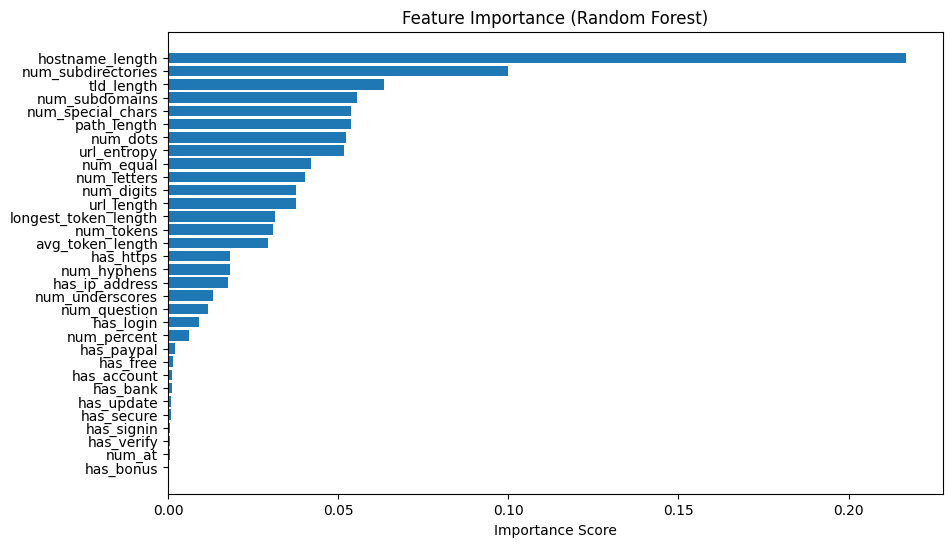

In [6]:
data = feature_df.copy()
data["type"] = df["type"].values

le = LabelEncoder()
y = le.fit_transform(data["type"])
X = data.drop(columns=["type"])

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

## Feature Reduction

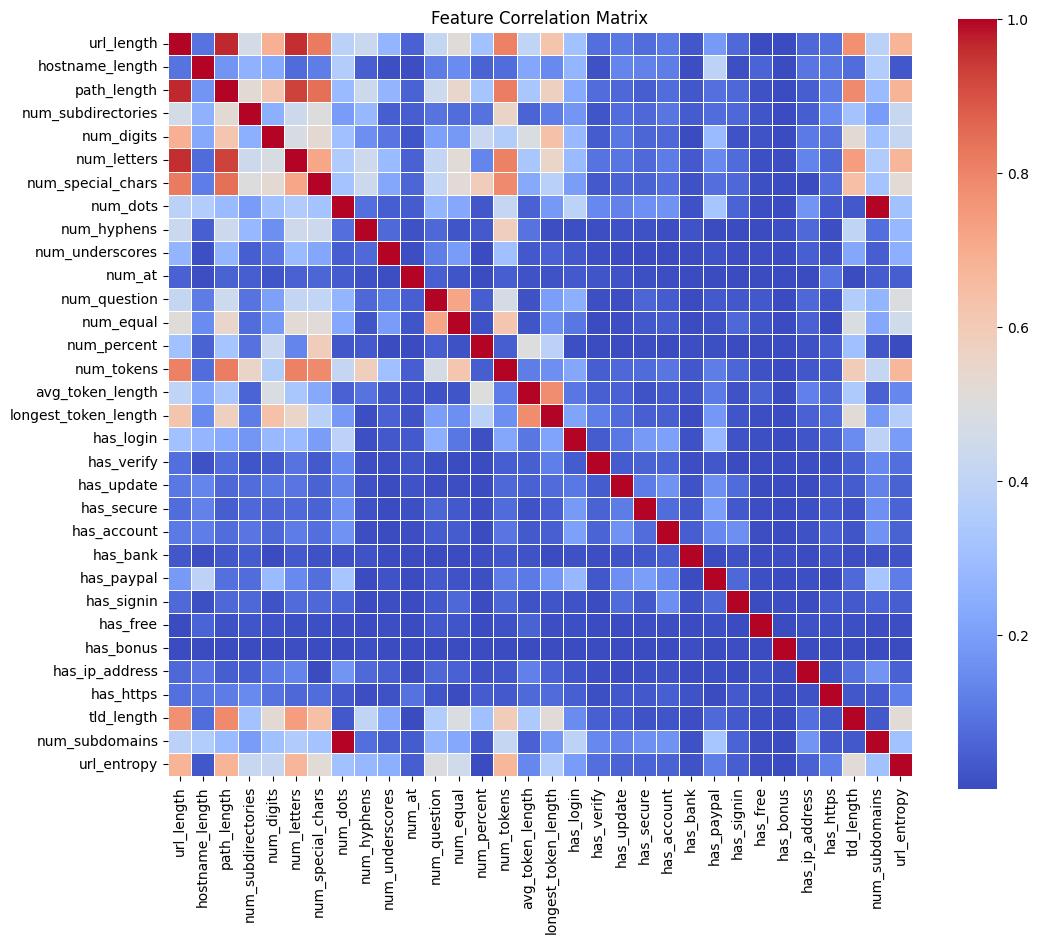

Dropped features: ['path_length', 'num_letters', 'num_subdomains']
Remaining features: 29


In [7]:
corr_matrix = feature_df.corr().abs()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar=True
)
plt.title("Feature Correlation Matrix")
plt.show()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

feature_df_reduced = feature_df.drop(columns=to_drop)

print("Dropped features:", to_drop)
print("Remaining features:", feature_df_reduced.shape[1])

In [8]:
print(feature_df_reduced.columns)

print("\n__________________\n")

feature_df_reduced.head()

Index(['url_length', 'hostname_length', 'num_subdirectories', 'num_digits',
       'num_special_chars', 'num_dots', 'num_hyphens', 'num_underscores',
       'num_at', 'num_question', 'num_equal', 'num_percent', 'num_tokens',
       'avg_token_length', 'longest_token_length', 'has_login', 'has_verify',
       'has_update', 'has_secure', 'has_account', 'has_bank', 'has_paypal',
       'has_signin', 'has_free', 'has_bonus', 'has_ip_address', 'has_https',
       'tld_length', 'url_entropy'],
      dtype='object')

__________________



,url_length,hostname_length,num_subdirectories,num_digits,num_special_chars,num_dots,num_hyphens,num_underscores,num_at,num_question,...,has_account,has_bank,has_paypal,has_signin,has_free,has_bonus,has_ip_address,has_https,tld_length,url_entropy
0,16.0,16.0,0.0,0.0,3.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.375000
1,35.0,11.0,2.0,1.0,5.0,2.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.079143
2,31.0,14.0,3.0,1.0,5.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.708093
3,88.0,5.0,3.0,7.0,18.0,3.0,1.0,2.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,4.660343
4,235.0,5.0,3.0,22.0,14.0,2.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,198.0,5.491293


## Data Balancing

In [9]:
print("Total NaNs:", feature_df_reduced.isna().sum().sum())

print("Total Rows:", feature_df_reduced["url_length"].count())

#feature_df_reduced = feature_df_reduced.dropna()

Total NaNs: 0
Total Rows: 641119


In [10]:
print(df["type"].value_counts())
print(df["type"].value_counts(normalize=True))

type
benign        428080
defacement     95308
phishing       94086
malware        23645
Name: count, dtype: int64
type
benign        0.667708
defacement    0.148659
phishing      0.146753
malware       0.036881
Name: proportion, dtype: float64


In [11]:
le = LabelEncoder()
y = le.fit_transform(df["type"])

X_train, X_test, y_train, y_test = train_test_split(
    feature_df_reduced,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [342464  76246  18916  75269]
After SMOTE: [342464 342464 342464 342464]


# Training XGBoost Classifier

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:37:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9397928624906414
Macro F1: 0.91789713174477

Classification Report:
               precision    recall  f1-score   support

      benign       0.98      0.95      0.96     85616
  defacement       0.96      0.99      0.97     19062
     malware       0.91      0.92      0.92      4729
    phishing       0.78      0.86      0.82     18817

    accuracy                           0.94    128224
   macro avg       0.91      0.93      0.92    128224
weighted avg       0.94      0.94      0.94    128224



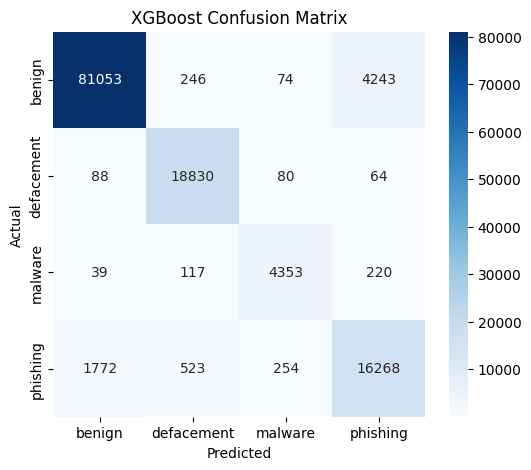

In [12]:
# model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

# Training Random Forest

Accuracy: 0.9580187796356376
Macro F1: 0.9408229249518684

Classification Report:
               precision    recall  f1-score   support

      benign       0.97      0.97      0.97     85616
  defacement       0.98      0.99      0.98     19062
     malware       0.96      0.93      0.94      4729
    phishing       0.87      0.86      0.86     18817

    accuracy                           0.96    128224
   macro avg       0.94      0.94      0.94    128224
weighted avg       0.96      0.96      0.96    128224



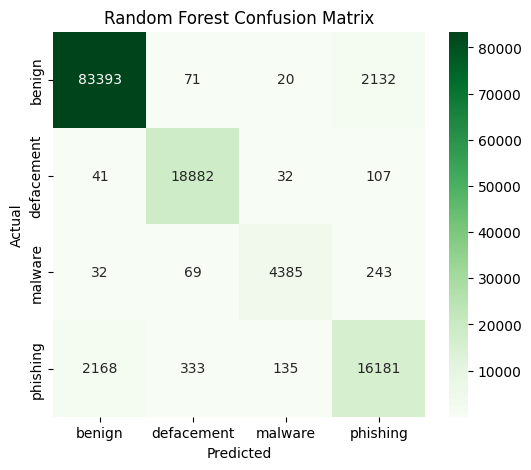

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf, target_names=le.classes_))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [14]:
import joblib

# Save models
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

print("Models saved successfully")

Models saved successfully


# Training 1D CNN

In [15]:
# Character-level tokenizer
tokenizer = Tokenizer(char_level=True, lower=True)
tokenizer.fit_on_texts(df["url"])

# Convert URLs to sequences
sequences = tokenizer.texts_to_sequences(df["url"])

# Pad sequences
MAX_LEN = 200
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")

le_seq = LabelEncoder()
y_seq = le_seq.fit_transform(df["type"])

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_seq),
    y=y_train_seq
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights:")
for key, value in class_weights_dict.items():
    print(key, value)

Class weights:
0 0.37441526700616706
1 1.681711171733599
2 6.778586910551914
3 1.7035399699743585


In [16]:
vocab_size = len(tokenizer.word_index) + 1

cnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=64),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(len(le_seq.classes_), activation='softmax')
])

cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn_model.summary()

I0000 00:00:1772707566.177911      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772707566.183546      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │        17,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,332 (263.02 KB)

 Trainable params: 67,332 (263.02 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = cnn_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights_dict,
    verbose=1
)

y_pred_cnn = np.argmax(cnn_model.predict(X_test_seq), axis=1)

print("Accuracy:", accuracy_score(y_test_seq, y_pred_cnn))
print("Macro F1:", f1_score(y_test_seq, y_pred_cnn, average="macro"))
print(classification_report(y_test_seq, y_pred_cnn, target_names=le_seq.classes_))

Epoch 1/5


I0000 00:00:1772707569.429078      94 service.cc:152] XLA service 0x7fb6fc039200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772707569.429119      94 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772707569.429123      94 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772707569.732023      94 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-05 10:46:11.821957: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.1 = (f32[128,64,1,200]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,128,1,196]{3,2,1,0} %bitcast.4318, f32[128,64,1,5]{3,2,1,0} %bitcast.4146), window={size=1x5}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/sequential_1/conv1d_1/convolution/Conv2DBackpropInput" source_file="/usr

  39/3206 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.4502 - loss: 1.3165

I0000 00:00:1772707576.458446      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3206/3206 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.8448 - loss: 0.4559 - val_accuracy: 0.9490 - val_loss: 0.1666
Epoch 2/5
3206/3206 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9284 - loss: 0.2156 - val_accuracy: 0.9575 - val_loss: 0.1437
Epoch 3/5
3206/3206 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9387 - loss: 0.1833 - val_accuracy: 0.9650 - val_loss: 0.1195
Epoch 4/5
3206/3206 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9429 - loss: 0.1710 - val_accuracy: 0.9642 - val_loss: 0.1243
Epoch 5/5
3206/3206 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9454 - loss: 0.1655 - val_accuracy: 0.9665 - val_loss: 0.1114
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Accuracy: 0.9666755053656102
Macro F1: 0.9547538892060898
              precision    recall  f1-score   support

      benign       0.99      0.97      0.98     85616
  defacement       0.98      0.99      0.99     19062
     malware       0.98      0.93      0.96      4729
    phishing       0.87      0.93      0.9

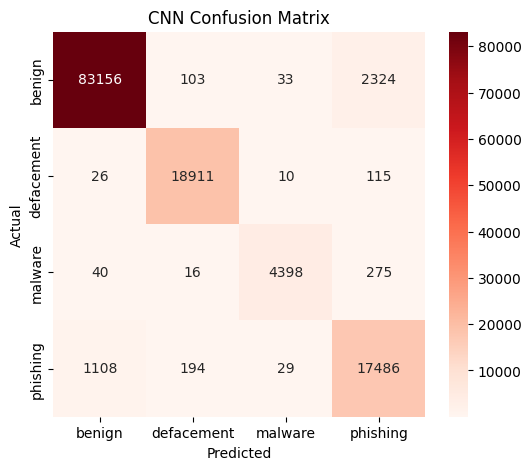

In [18]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test_seq, y_pred_cnn),
            annot=True,
            fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()